In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Sequential
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Load and prepare data
df = pd.read_csv('final_df_bgd_bgd.csv')

# Data preparation
drop_cols = ['matched_weight', 'required_weight', 'missing_hard_skills',
             'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
             'missing_soft_skills_new', 'final_score']
df2 = df.drop(columns=drop_cols)

# One-hot encode domain
df2 = pd.get_dummies(df2, columns=['domain'], prefix='domain', dtype=int)

In [ ]:
df.shape

(10176, 17)

In [ ]:
df.columns

Index(['cv_id', 'jd_id', 'matched_weight', 'required_weight', 'match_ratio',
       'missing_required_skills_count', 'missing_hard_skills',
       'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_new', 'missing_soft_skills_count_new', 'domain',
       'final_score', 'target'],
      dtype='object')

In [ ]:
df['cv_id'].nunique()

32

In [ ]:
df['jd_id'].nunique()

318

In [ ]:
df['target'].value_counts()

,count
target,
0,7809
1,2367


In [ ]:
df.isnull().sum()

,0
cv_id,0
jd_id,0
matched_weight,0
required_weight,0
match_ratio,0
missing_required_skills_count,0
missing_hard_skills,0
missing_soft_skills,0
required_hard_skills,0
required_soft_skills,0


In [ ]:
df2.head()

,cv_id,jd_id,match_ratio,missing_required_skills_count,required_skill_count,soft_skill_match_score,missing_soft_skills_count_new,domain,target
0,1,1,1.000000,0,5,0.779042,0,Support,1
1,1,2,0.750000,1,6,0.576355,1,IT,1
2,1,3,0.333333,2,6,0.757210,0,Business,0
3,1,4,0.333333,2,9,0.698309,1,Business,0
4,1,5,0.625000,3,18,0.710335,2,Business,1


In [ ]:
df2.columns

Index(['cv_id', 'jd_id', 'match_ratio', 'missing_required_skills_count',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_count_new', 'domain', 'target'],
      dtype='object')

In [ ]:
df2['domain'].unique()

array(['Support', 'IT', 'Business', 'Finance', 'Engineering',
       'Administrative', 'Creative', 'HR', 'Research', 'Operations',
       'Management', 'Consulting', 'Analytics'], dtype=object)

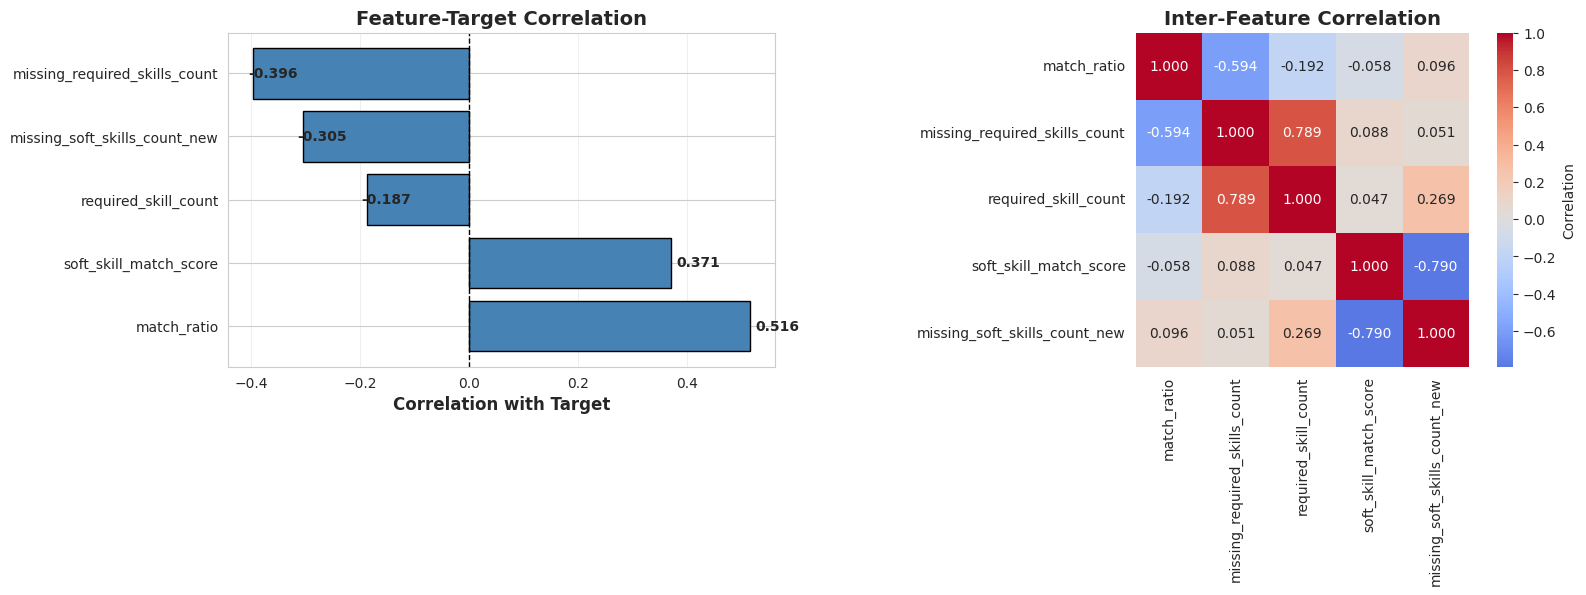

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation with target
axes[0].barh(correlations.index, correlations.values, color='steelblue', edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Correlation with Target', fontsize=12, fontweight='bold')
axes[0].set_title('Feature-Target Correlation', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add correlation values as text
for i, (feat, val) in enumerate(correlations.items()):
    axes[0].text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}',
                 va='center', fontweight='bold')

# Inter-feature correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Inter-Feature Correlation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Create interaction features
df2['skill_match_product'] = df2['match_ratio'] * df2['soft_skill_match_score']
df2['total_missing_skills'] = df2['missing_required_skills_count'] + df2['missing_soft_skills_count_new']
df2['skill_completeness'] = 1 / (1 + df2['total_missing_skills'])
df2['hard_soft_ratio'] = df2['match_ratio'] / (df2['soft_skill_match_score'] + 0.01)
df2['hard_skill_squared'] = df2['match_ratio'] ** 2
df2['soft_skill_squared'] = df2['soft_skill_match_score'] ** 2

# Drop highly correlated feature
df2 = df2.drop(columns=['skill_match_product'])

In [ ]:
# Define columns
id_cols = ['cv_id', 'jd_id']
target_col = 'target'
feature_cols = [col for col in df2.columns if col not in id_cols + [target_col]]

# Prepare data
X = df2[feature_cols].copy()
y = df2[target_col].copy()
groups = df2['cv_id'].copy()

In [ ]:
# Split data
gss1 = GroupShuffleSplit(test_size=0.35, n_splits=1, random_state=1000)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
cv_train = groups.iloc[train_idx]

X_ = X.iloc[temp_idx]
y_ = y.iloc[temp_idx]
cv_ = groups.iloc[temp_idx]

In [ ]:
gss2 = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=2024)
test_idx, val_idx = next(gss2.split(X_, y_, groups=cv_))

X_test = X_.iloc[test_idx]
y_test = y_.iloc[test_idx]
cv_test = cv_.iloc[test_idx]

X_val = X_.iloc[val_idx]
y_val = y_.iloc[val_idx]
cv_val = cv_.iloc[val_idx]

In [ ]:
# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
# Clear session
keras.backend.clear_session()

In [ ]:
def ranking_hinge_loss(y_true, y_pred, margin=1.0):
    """
    Simplified hinge loss for ranking
    This version works with standard batch processing
    """
    # Reshape
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    # Get positive and negative samples
    pos_mask = tf.cast(tf.equal(y_true, 1), tf.float32)
    neg_mask = tf.cast(tf.equal(y_true, 0), tf.float32)

    # Get positive and negative scores
    pos_scores = y_pred * pos_mask
    neg_scores = y_pred * neg_mask

    # Create valid pairs: for each positive, compare with all negatives
    # This is simplified to work with batch processing
    pos_scores_expanded = tf.expand_dims(pos_scores, 1)  # [batch, 1]
    neg_scores_expanded = tf.expand_dims(neg_scores, 0)  # [1, batch]

    # Create pair differences
    score_diffs = pos_scores_expanded - neg_scores_expanded  # [pos_count, neg_count]

    # Apply hinge loss
    losses = tf.maximum(0.0, margin - score_diffs)

    # Count valid pairs
    valid_pairs = tf.expand_dims(pos_mask, 1) * tf.expand_dims(neg_mask, 0)

    # Mask invalid pairs and average
    masked_losses = losses * valid_pairs
    num_valid_pairs = tf.reduce_sum(valid_pairs) + 1e-10

    return tf.reduce_sum(masked_losses) / num_valid_pairs

In [ ]:
class MRRMetric(keras.metrics.Metric):
    """Mean Reciprocal Rank - Fixed version"""

    def __init__(self, name='mrr', **kwargs):
        super().__init__(name=name, **kwargs)
        self.mrr_sum = self.add_weight(name='mrr_sum', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(y_pred, [-1])
        y_true = tf.reshape(y_true, [-1])

        # Get indices sorted by predicted score (descending)
        sorted_indices = tf.argsort(y_pred, direction='DESCENDING')

        # Get true labels in sorted order
        sorted_labels = tf.gather(y_true, sorted_indices)

        # Get indices of relevant items (y_true == 1) in the sorted list
        relevant_indices_in_sorted = tf.where(sorted_labels > 0) # Changed 0.5 to 0

        # Use tf.cond for graph-compatible conditional logic
        reciprocal_rank_value = tf.cond(
            tf.cast(tf.shape(relevant_indices_in_sorted)[0], tf.bool), # Check if num relevant > 0
            lambda: 1.0 / tf.cast(relevant_indices_in_sorted[0][0] + 1, tf.float32),
            lambda: 0.0
        )

        # Always update sum and count for this batch
        self.mrr_sum.assign_add(reciprocal_rank_value)
        self.count.assign_add(1.0) # Increment count for each batch processed

    def result(self):
        return self.mrr_sum / tf.maximum(self.count, 1.0)

    def reset_state(self):
        self.mrr_sum.assign(0.0)
        self.count.assign(0.0)

In [ ]:
class PrecisionAtK(keras.metrics.Metric):
    """Precision at K - Fixed version"""

    def __init__(self, k=5, name='precision_at_k', **kwargs):
        super().__init__(name=name, **kwargs)
        self.k = k
        self.precision_sum = self.add_weight(name='precision_sum', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(y_pred, [-1])
        y_true = tf.reshape(y_true, [-1])

        k_actual = tf.minimum(self.k, tf.shape(y_pred)[0])

        precision = tf.cond(
            tf.equal(k_actual, 0), # If k_actual is 0, precision is 0
            lambda: 0.0,
            lambda: (
                tf.reduce_sum(tf.cast(tf.gather(y_true, tf.nn.top_k(y_pred, k=k_actual).indices), tf.float32))
                / tf.cast(k_actual, tf.float32)
            )
        )

        self.precision_sum.assign_add(precision)
        self.count.assign_add(1.0)

    def result(self):
        return self.precision_sum / tf.maximum(self.count, 1.0)

    def reset_state(self):
        self.precision_sum.assign(0.0)
        self.count.assign(0.0)

In [ ]:
input_dim = X_train_scaled.shape[1]
l2_reg = 0.5
dropout_rate = 0.6

In [ ]:
model = Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),

    layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ),
    layers.BatchNormalization(),
    layers.Dropout(dropout_rate),

    layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Create metric instances
mrr_metric = MRRMetric(name='mrr')
p_at_1 = PrecisionAtK(k=1, name='p@1')
p_at_3 = PrecisionAtK(k=3, name='p@3')
p_at_5 = PrecisionAtK(k=5, name='p@5')
p_at_10 = PrecisionAtK(k=10, name='p@10')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=ranking_hinge_loss,  # Using the fixed hinge loss
    metrics=[
        mrr_metric,           # MRR metric
        p_at_1,               # Precision@1
        p_at_3,               # Precision@3
        p_at_5,               # Precision@5
        p_at_10,              # Precision@10
        keras.metrics.AUC(name='auc')  # AUC for completeness
    ]
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

None


In [ ]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_mrr',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_mrr',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_ranking_model.keras',
    monitor='val_mrr',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Class weights
class_weight_ratio = (1 / y_train.mean()) - 1
class_weight = {0: 1.0, 1: class_weight_ratio}
print(f"Positive class ratio: {y_train.mean():.4f}")
print(f"Class weights: {class_weight}")

Positive class ratio: 0.2181
Class weights: {0: 1.0, 1: np.float64(3.585436193222783)}


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

Epoch 1/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.5459 - loss: 35.0723 - mrr: 0.6973 - p@1: 0.5199 - p@10: 0.3084 - p@3: 0.4323 - p@5: 0.3644
Epoch 1: val_mrr improved from -inf to 0.75000, saving model to best_ranking_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - auc: 0.5468 - loss: 34.9851 - mrr: 0.6979 - p@1: 0.5209 - p@10: 0.3092 - p@3: 0.4330 - p@5: 0.3654 - val_auc: 0.9473 - val_loss: 22.0563 - val_mrr: 0.7500 - val_p@1: 0.7333 - val_p@10: 0.5067 - val_p@3: 0.6444 - val_p@5: 0.5933 - learning_rate: 5.0000e-04
Epoch 2/100
 90/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7578 - loss: 19.9973 - mrr: 0.8834 - p@1: 0.7846 - p@10: 0.5722 - p@3: 0.7444 - p@5: 0.6745
Epoch 2: val_mrr did not improve from 0.75000
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.7612 - loss: 19.7097 - mrr: 0.8858 - p@1: 0.7889 - p@10: 0.5735 - p@3: 0.7471 - p@5: 0.6772 - val_auc: 0.9547 - val_loss: 12.1658 - val_mrr: 0.7083 - val_p@1: 0.6667 - val_p@10: 0.5167 - val_p@3: 0.6111 - va

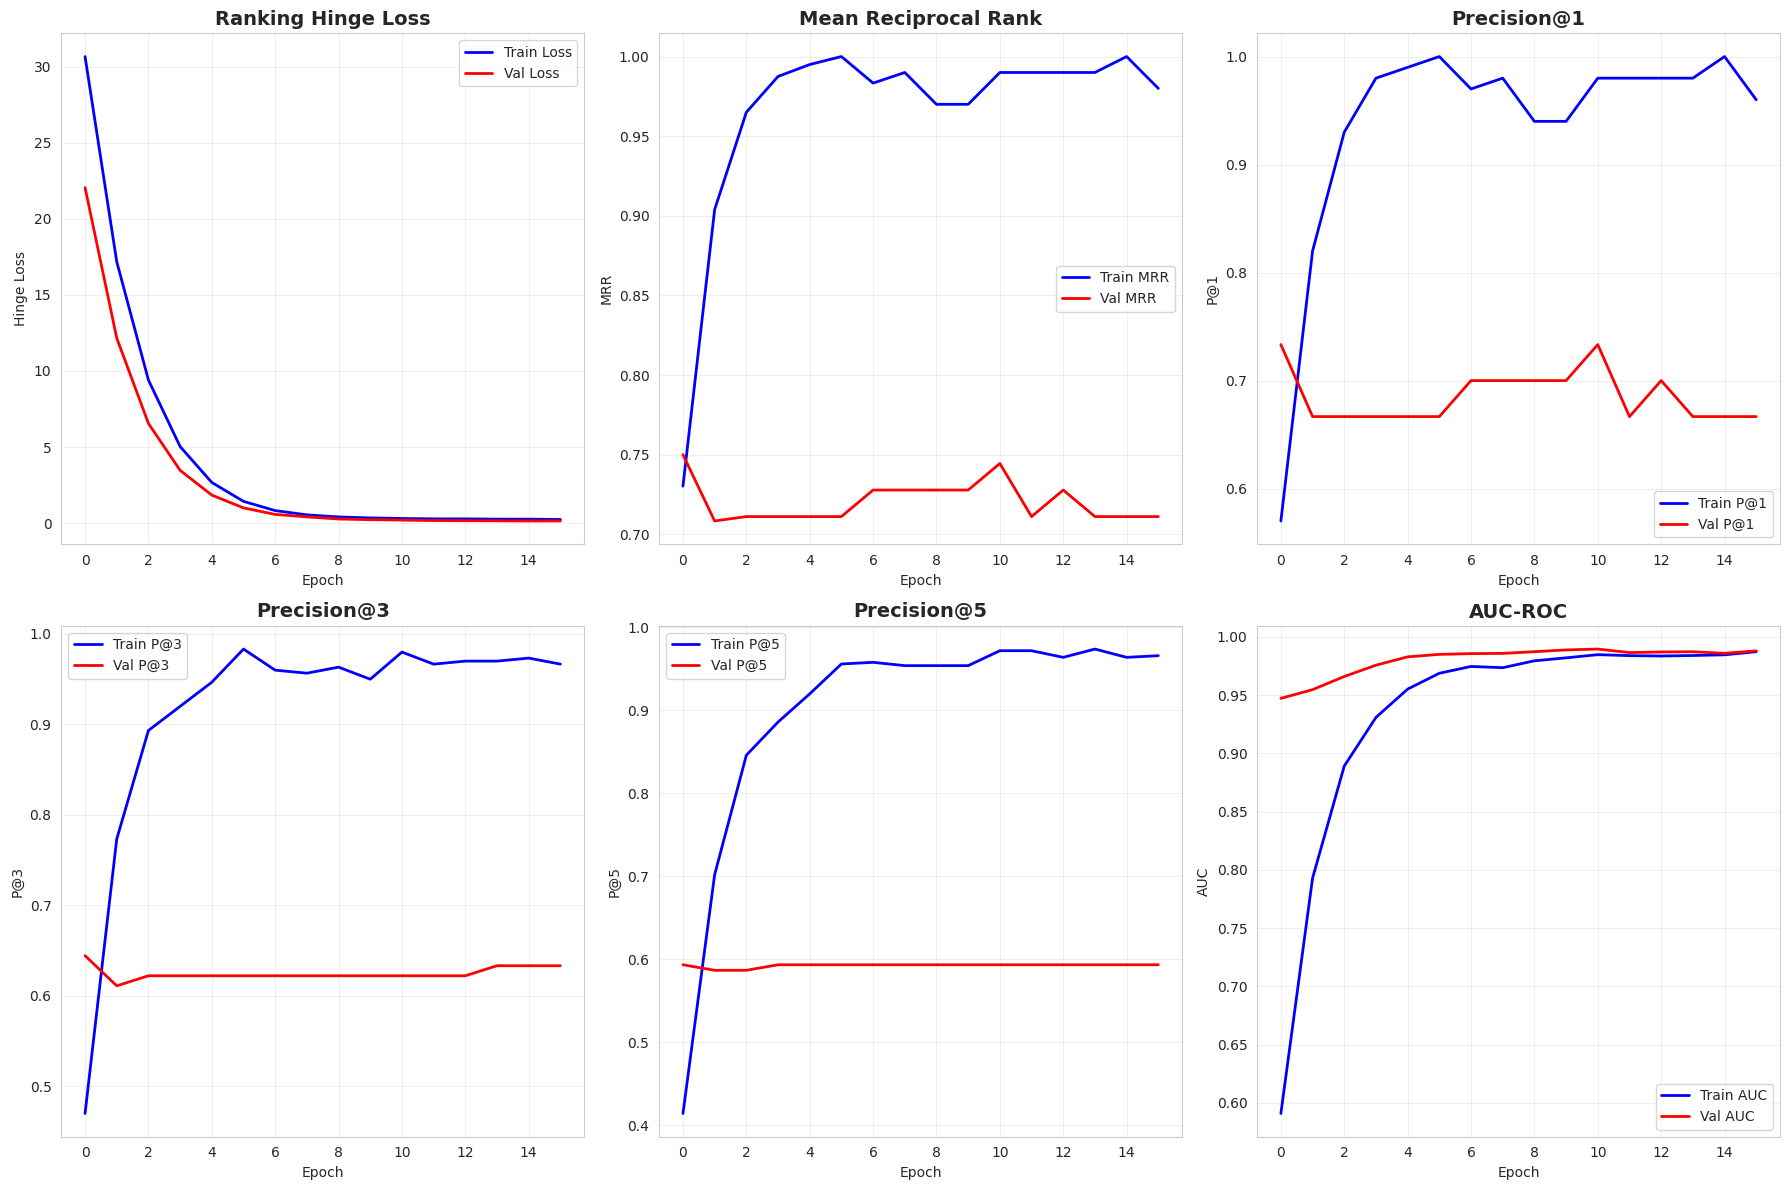

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Hinge Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
axes[0, 0].set_title('Ranking Hinge Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Hinge Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MRR (Primary Metric)
axes[0, 1].plot(history.history['mrr'], label='Train MRR', linewidth=2, color='blue')
axes[0, 1].plot(history.history['val_mrr'], label='Val MRR', linewidth=2, color='red')
axes[0, 1].set_title('Mean Reciprocal Rank', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MRR')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# P@1
axes[0, 2].plot(history.history['p@1'], label='Train P@1', linewidth=2, color='blue')
axes[0, 2].plot(history.history['val_p@1'], label='Val P@1', linewidth=2, color='red')
axes[0, 2].set_title('Precision@1', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('P@1')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# P@3
axes[1, 0].plot(history.history['p@3'], label='Train P@3', linewidth=2, color='blue')
axes[1, 0].plot(history.history['val_p@3'], label='Val P@3', linewidth=2, color='red')
axes[1, 0].set_title('Precision@3', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('P@3')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# P@5
axes[1, 1].plot(history.history['p@5'], label='Train P@5', linewidth=2, color='blue')
axes[1, 1].plot(history.history['val_p@5'], label='Val P@5', linewidth=2, color='red')
axes[1, 1].set_title('Precision@5', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('P@5')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# AUC
axes[1, 2].plot(history.history['auc'], label='Train AUC', linewidth=2, color='blue')
axes[1, 2].plot(history.history['val_auc'], label='Val AUC', linewidth=2, color='red')
axes[1, 2].set_title('AUC-ROC', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUC')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Total epochs run: {len(history.history['loss'])}")
print(f"Best epoch (by val_mrr): {np.argmax(history.history['val_mrr']) + 1}")
print(f"\nBest validation metrics:")
print(f"  MRR:      {max(history.history['val_mrr']):.4f}")
print(f"  P@1:      {max(history.history['val_p@1']):.4f}")
print(f"  P@3:      {max(history.history['val_p@3']):.4f}")
print(f"  P@5:      {max(history.history['val_p@5']):.4f}")
print(f"  AUC:      {max(history.history['val_auc']):.4f}")

Total epochs run: 16
Best epoch (by val_mrr): 1

Best validation metrics:
  MRR:      0.7500
  P@1:      0.7333
  P@3:      0.6444
  P@5:      0.5933
  AUC:      0.9896


In [ ]:
# Get predictions
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics manually for test set
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(y_test, y_test_pred)
print(f"Test AUC: {test_auc:.4f}")

# For ranking metrics on test set
# You might want to calculate these per CV group
print("\nNote: For proper ranking evaluation, consider calculating metrics per CV group")
print("and then averaging across groups.")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test AUC: 0.9691

Note: For proper ranking evaluation, consider calculating metrics per CV group
and then averaging across groups.
